<div style="background-color:#263238;color:white;padding:18px;border-radius:8px;text-align:center;">
<h1>Financial Performance Analytics of Indian Listed Companies</h1>
<h3>Financial Statement Analytics | Indian Equities | Business Insights</h3>
<p>Portfolio project for Business Analytics, Analytics Consulting, Strategy Analytics, and Financial Analytics roles</p>
</div>

**Research question:** How can financial statement analytics be used to evaluate company performance and generate actionable business insights?

**Core narrative:** Data -> Analysis -> Insight -> Business Recommendation

**Data sources:** Screener.in public company financial statements, supplemented with Yahoo Finance through `yfinance` for market capitalization and selected ratio inputs. The cached dataset was collected on **July 3, 2026** for reproducibility.

## 1. Problem Statement

Indian listed companies operate across sectors with very different margin structures, capital intensity, and balance-sheet risk. A manager, analyst, or consultant needs a structured way to compare these firms beyond headline revenue and profit.

This project builds a financial analytics framework to evaluate profitability, growth, liquidity, leverage, asset efficiency, cash generation, and sector-level performance across large Indian listed companies.

**Business objective:** identify financially stronger firms, sector-level performance patterns, and risk signals that can inform investment screening, strategic benchmarking, and management action.

## 2. Business Context

The analysis is designed for a consulting-style discussion rather than a trading recommendation. It asks:

- Which sectors show superior profitability and capital efficiency?
- Which companies combine growth with financial discipline?
- Is leverage associated with lower profitability?
- Does company size explain profitability?
- Which firms need closer risk monitoring because of weak margins, high leverage, or poor cash conversion?

The notebook intentionally focuses on explainable financial ratios, EDA, statistical reasoning, and business recommendations.

## 3. Data Collection

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

DATA_DIR = Path("data")
PRIMARY_DATA = DATA_DIR / "screener_financial_statements_panel.csv"
YFINANCE_DATA = DATA_DIR / "financial_statements_panel.csv"

primary_raw = pd.read_csv(PRIMARY_DATA)
yf_raw = pd.read_csv(YFINANCE_DATA)

print(f"Primary Screener statement panel: {primary_raw.shape[0]:,} rows, {primary_raw['ticker'].nunique()} companies")
print(f"Supplemental yfinance panel: {yf_raw.shape[0]:,} rows, {yf_raw['ticker'].nunique()} companies")
print(f"Primary coverage: FY{primary_raw['financial_year'].min()} to FY{primary_raw['financial_year'].max()}")

Primary Screener statement panel: 567 rows, 48 companies
Supplemental yfinance panel: 243 rows, 49 companies
Primary coverage: FY2014 to FY2026


**Collection approach**

- Screener.in was used for multi-year P&L, balance sheet, and cash-flow statements because it provides deeper Indian company history than the current Yahoo Finance annual endpoint for several tickers.
- Yahoo Finance via `yfinance` was used as a supplemental source for market capitalization, gross profit, current assets, current liabilities, inventory, and EBITDA where available.
- The project uses locally cached CSV files so the notebook remains reproducible even if a website throttles or a ticker changes.
- Monetary fields are stated in **INR crore**.

## 4. Data Understanding

In [2]:
primary_raw.head()

,ticker,company,sector,financial_year,revenue_cr,expenses_cr,operating_profit_cr,operating_margin_pct_reported,interest_cr,depreciation_cr,profit_before_tax_cr,tax_pct_reported,net_profit_cr,eps_rs,dividend_payout_pct,equity_capital_cr,reserves_cr,equity_cr,borrowings_cr,deposits_cr,other_liabilities_cr,total_liabilities_cr,fixed_assets_cr,cwip_cr,investments_cr,other_assets_cr,total_assets_cr,operating_cash_flow_cr,investing_cash_flow_cr,financing_cash_flow_cr,net_cash_flow_cr,free_cash_flow_cr
0,ADANIENT.NS,Adani Enterprises,Conglomerate,2015,"64,465.00","52,015.00","12,450.00",19.00,"7,056.00","3,522.00","2,663.00",14.00,"2,298.00",15.81,8.00,110.00,"25,618.00","25,728.00","83,571.00",NaN,"21,420.00","130,718.00","83,834.00","6,733.00",744.00,"39,407.00","130,718.00","8,532.00","-11,465.00","3,445.00",512.00,-621.00
1,ADANIENT.NS,Adani Enterprises,Conglomerate,2016,"34,008.00","32,325.00","1,684.00",5.00,"1,357.00",314.00,"1,056.00",7.00,"1,000.00",8.21,4.00,110.00,"13,268.00","13,378.00","19,169.00",NaN,"9,132.00","41,679.00","10,473.00","7,705.00",805.00,"22,696.00","41,679.00","5,112.00","-1,825.00","-3,448.00",-161.00,-778.00
2,ADANIENT.NS,Adani Enterprises,Conglomerate,2017,"36,533.00","34,631.00","1,902.00",5.00,"1,257.00",315.00,"1,079.00",25.00,925.00,8.02,4.00,110.00,"14,026.00","14,136.00","20,846.00",NaN,"12,630.00","47,611.00","13,668.00","7,731.00","1,042.00","25,170.00","47,611.00",774.00,"-1,460.00",716.00,30.00,"-3,373.00"
3,ADANIENT.NS,Adani Enterprises,Conglomerate,2018,"35,924.00","33,886.00","2,038.00",6.00,"1,250.00",664.00,487.00,23.00,594.00,6.15,6.00,110.00,"14,979.00","15,089.00","17,637.00",NaN,"23,679.00","56,405.00","10,555.00","5,526.00","1,461.00","38,864.00","56,405.00","2,942.00","-7,649.00","5,120.00",413.00,"-4,352.00"
4,ADANIENT.NS,Adani Enterprises,Conglomerate,2019,"40,379.00","38,409.00","1,969.00",5.00,"1,625.00",390.00,459.00,32.00,506.00,5.82,6.00,110.00,"14,646.00","14,756.00","11,243.00",NaN,"16,537.00","42,536.00","9,020.00","5,765.00","1,511.00","26,240.00","42,536.00","3,236.00","2,487.00","-6,158.00",-436.00,"1,471.00"


In [3]:
overview = pd.DataFrame({
    "metric": [
        "Rows",
        "Companies",
        "Sectors",
        "Financial years",
        "Min year",
        "Max year"
    ],
    "value": [
        len(primary_raw),
        primary_raw["ticker"].nunique(),
        primary_raw["sector"].nunique(),
        primary_raw["financial_year"].nunique(),
        int(primary_raw["financial_year"].min()),
        int(primary_raw["financial_year"].max())
    ]
})
overview

,metric,value
0,Rows,567
1,Companies,48
2,Sectors,19
3,Financial years,13
4,Min year,2014
5,Max year,2026


In [4]:
missing_summary = (
    primary_raw.isna().mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_pct"})
)
missing_summary.head(12)

,column,missing_pct
0,deposits_cr,87.50
1,equity_capital_cr,0.20
2,financing_cash_flow_cr,0.20
3,net_cash_flow_cr,0.20
4,operating_cash_flow_cr,0.20
5,total_assets_cr,0.20
6,other_assets_cr,0.20
7,investing_cash_flow_cr,0.20
8,cwip_cr,0.20
9,fixed_assets_cr,0.20


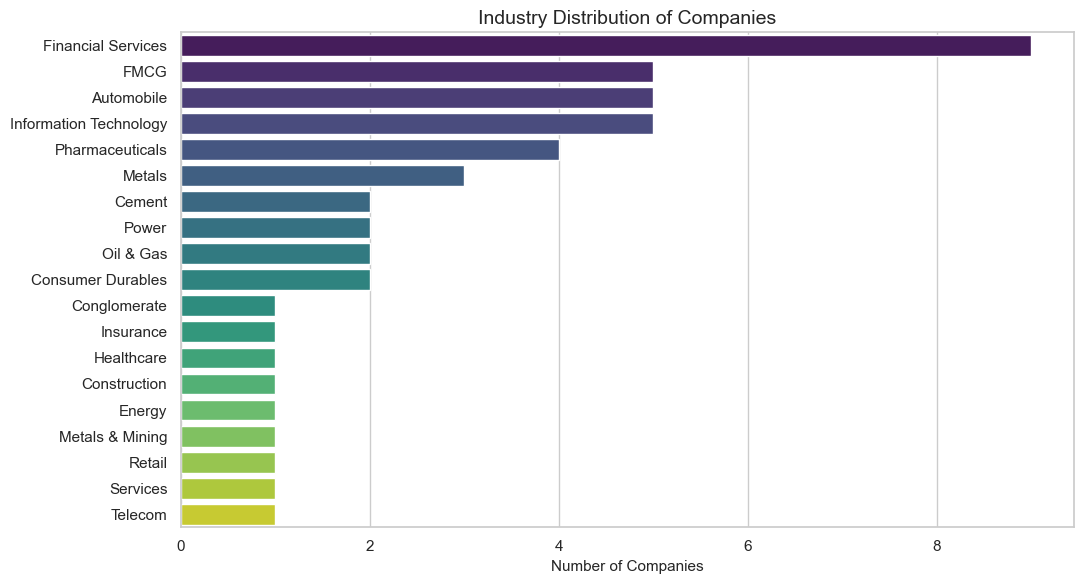


### Observation
The panel covers **48 companies** across **19 sectors**, with Financial Services, FMCG, Automobile, and Information Technology among the most represented groups.

### Business Interpretation
The dataset is broad enough for cross-sector benchmarking, but the sector mix is not equal. Large sectors will influence aggregate results more strongly than niche sectors with one or two companies.

### Recommendation
Use company-level and sector-level views together. Sector medians are more reliable than sector averages when the number of companies is small or when a sector contains very large outliers.


In [5]:
sector_distribution = (
    primary_raw.groupby("sector")["ticker"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="companies")
)

ax = sns.barplot(data=sector_distribution, y="sector", x="companies", palette="viridis")
ax.set_title("Industry Distribution of Companies")
ax.set_xlabel("Number of Companies")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

display(Markdown(f'''
### Observation
The panel covers **{primary_raw['ticker'].nunique()} companies** across **{primary_raw['sector'].nunique()} sectors**, with Financial Services, FMCG, Automobile, and Information Technology among the most represented groups.

### Business Interpretation
The dataset is broad enough for cross-sector benchmarking, but the sector mix is not equal. Large sectors will influence aggregate results more strongly than niche sectors with one or two companies.

### Recommendation
Use company-level and sector-level views together. Sector medians are more reliable than sector averages when the number of companies is small or when a sector contains very large outliers.
'''))

## 5. Data Cleaning

In [6]:
df = primary_raw.copy()

# Standardize identifiers and remove accidental duplicates.
df["ticker"] = df["ticker"].str.upper().str.strip()
df["company"] = df["company"].str.strip()
df["sector"] = df["sector"].str.strip()
df = df.drop_duplicates(subset=["ticker", "financial_year"]).sort_values(["ticker", "financial_year"])

# Keep a balanced recent analysis window. Most companies have FY2022-FY2026.
analysis_years = sorted(df["financial_year"].unique())[-5:]
df = df[df["financial_year"].isin(analysis_years)].copy()

company_year_counts = df.groupby("ticker")["financial_year"].nunique()
eligible_tickers = company_year_counts[company_year_counts == 5].index
df = df[df["ticker"].isin(eligible_tickers)].copy()

print(f"Analysis window: FY{min(analysis_years)}-FY{max(analysis_years)}")
print(f"Companies retained with complete 5-year coverage: {df['ticker'].nunique()}")
print(f"Company-year rows retained: {len(df)}")

Analysis window: FY2022-FY2026
Companies retained with complete 5-year coverage: 47
Company-year rows retained: 235


In [7]:
# Add yfinance supplemental fields for current market cap, gross profit, current ratio and quick ratio.
yf = yf_raw.copy()
yf_fields = [
    "ticker", "financial_year", "market_cap_cr", "gross_profit_cr", "ebitda_cr",
    "current_assets_cr", "current_liabilities_cr", "inventory_cr"
]
yf = yf[[c for c in yf_fields if c in yf.columns]].copy()
yf = yf.rename(columns={
    "gross_profit_cr": "gross_profit_yf_cr",
    "ebitda_cr": "ebitda_yf_cr",
    "current_assets_cr": "current_assets_yf_cr",
    "current_liabilities_cr": "current_liabilities_yf_cr",
    "inventory_cr": "inventory_yf_cr"
})

df = df.merge(yf, on=["ticker", "financial_year"], how="left")
company_market_cap = (
    yf.dropna(subset=["market_cap_cr"])
    .groupby("ticker")["market_cap_cr"]
    .median()
)
df["market_cap_cr"] = df["ticker"].map(company_market_cap)

core_cols = ["revenue_cr", "net_profit_cr", "total_assets_cr", "total_liabilities_cr", "equity_cr", "operating_cash_flow_cr"]
before = len(df)
df = df.dropna(subset=core_cols)
print(f"Dropped {before - len(df)} rows with missing core financial statement fields.")

# Consistency check: assets should approximately equal liabilities on Screener's balance sheet format.
df["balance_sheet_gap_pct"] = ((df["total_assets_cr"] - df["total_liabilities_cr"]).abs() / df["total_assets_cr"]).replace([np.inf, -np.inf], np.nan)
print("Median balance-sheet gap:", f"{df['balance_sheet_gap_pct'].median():.4%}")

Dropped 0 rows with missing core financial statement fields.
Median balance-sheet gap: 0.0000%


In [8]:
def safe_divide(numerator, denominator):
    return np.where((denominator == 0) | pd.isna(denominator), np.nan, numerator / denominator)

df["gross_margin"] = safe_divide(df["gross_profit_yf_cr"], df["revenue_cr"])
df["operating_margin"] = safe_divide(df["operating_profit_cr"], df["revenue_cr"])
df["net_profit_margin"] = safe_divide(df["net_profit_cr"], df["revenue_cr"])
df["roa"] = safe_divide(df["net_profit_cr"], df["total_assets_cr"])
df["roe"] = safe_divide(df["net_profit_cr"], df["equity_cr"])
df["debt_to_equity"] = safe_divide(df["borrowings_cr"], df["equity_cr"])
df["asset_turnover"] = safe_divide(df["revenue_cr"], df["total_assets_cr"])
df["interest_coverage"] = safe_divide(df["operating_profit_cr"], df["interest_cr"].abs())
df["ebitda_margin"] = safe_divide(df["ebitda_yf_cr"].fillna(df["operating_profit_cr"] + df["depreciation_cr"]), df["revenue_cr"])
df["free_cash_flow_margin"] = safe_divide(df["free_cash_flow_cr"], df["revenue_cr"])
df["cfo_to_profit"] = safe_divide(df["operating_cash_flow_cr"], df["net_profit_cr"])
df["current_ratio"] = safe_divide(df["current_assets_yf_cr"], df["current_liabilities_yf_cr"])
df["quick_ratio"] = safe_divide(df["current_assets_yf_cr"] - df["inventory_yf_cr"].fillna(0), df["current_liabilities_yf_cr"])

df = df.sort_values(["ticker", "financial_year"])
df["revenue_growth"] = df.groupby("ticker")["revenue_cr"].pct_change()
df["profit_growth"] = df.groupby("ticker")["net_profit_cr"].pct_change()

ratio_cols = [
    "gross_margin", "operating_margin", "net_profit_margin", "roa", "roe",
    "debt_to_equity", "current_ratio", "quick_ratio", "asset_turnover",
    "revenue_growth", "profit_growth", "interest_coverage", "ebitda_margin",
    "free_cash_flow_margin", "cfo_to_profit"
]

# Winsorized copies limit chart distortion from extreme ratios while preserving raw values.
for col in ratio_cols:
    low, high = df[col].quantile([0.01, 0.99])
    df[col + "_w"] = df[col].clip(low, high)

df[["ticker", "company", "sector", "financial_year", "revenue_cr", "net_profit_cr", "operating_margin", "roe", "debt_to_equity"]].head()

,ticker,company,sector,financial_year,revenue_cr,net_profit_cr,operating_margin,roe,debt_to_equity
0,ADANIENT.NS,Adani Enterprises,Conglomerate,2022,"69,420.00",788.00,0.05,0.04,1.87
1,ADANIENT.NS,Adani Enterprises,Conglomerate,2023,"127,540.00","2,422.00",0.07,0.07,1.61
2,ADANIENT.NS,Adani Enterprises,Conglomerate,2024,"96,421.00","3,335.00",0.12,0.09,1.67
3,ADANIENT.NS,Adani Enterprises,Conglomerate,2025,"97,895.00","8,005.00",0.15,0.16,1.82
4,ADANIENT.NS,Adani Enterprises,Conglomerate,2026,"100,469.00","9,951.00",0.14,0.12,1.32


**Cleaning decisions**

- The analysis is restricted to the latest complete five-year window, FY2022-FY2026.
- Companies without complete five-year coverage are excluded from the main analysis to support like-for-like comparisons.
- Missing current-ratio, quick-ratio, and gross-margin values are retained rather than forced, because these fields are not consistently meaningful for banks, insurers, and some Screener statement formats.
- Extreme ratio values are winsorized only for visualization and scoring. Raw calculated ratios remain available.

## 6. Exploratory Data Analysis

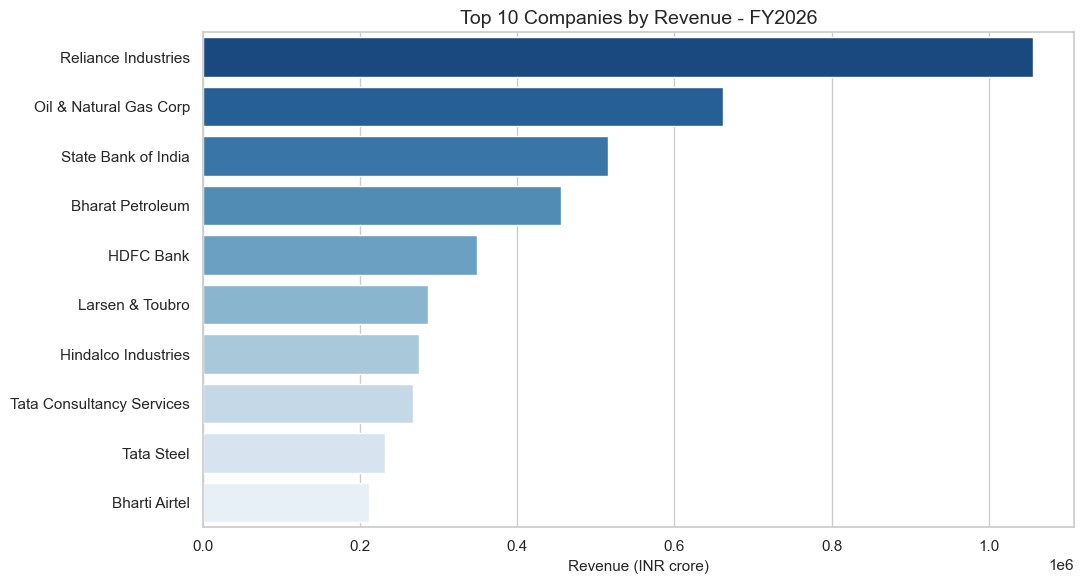


### Observation
**Reliance Industries** is the largest company by FY2026 revenue in the analysis panel, with revenue of approximately **INR 1,055,780 crore**.

### Business Interpretation
Revenue leadership is concentrated in large-scale, asset-heavy businesses. Size creates operating leverage but does not automatically translate into superior margins or returns.

### Recommendation
Use revenue ranking as a scale indicator, then evaluate margin, ROE, leverage, and cash conversion before calling a company financially attractive.


In [9]:
latest_year = int(df["financial_year"].max())
latest = df[df["financial_year"] == latest_year].copy()

top_revenue = latest.nlargest(10, "revenue_cr")
ax = sns.barplot(data=top_revenue, x="revenue_cr", y="company", palette="Blues_r")
ax.set_title(f"Top 10 Companies by Revenue - FY{latest_year}")
ax.set_xlabel("Revenue (INR crore)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

leader = top_revenue.iloc[0]
display(Markdown(f'''
### Observation
**{leader['company']}** is the largest company by FY{latest_year} revenue in the analysis panel, with revenue of approximately **INR {leader['revenue_cr']:,.0f} crore**.

### Business Interpretation
Revenue leadership is concentrated in large-scale, asset-heavy businesses. Size creates operating leverage but does not automatically translate into superior margins or returns.

### Recommendation
Use revenue ranking as a scale indicator, then evaluate margin, ROE, leverage, and cash conversion before calling a company financially attractive.
'''))

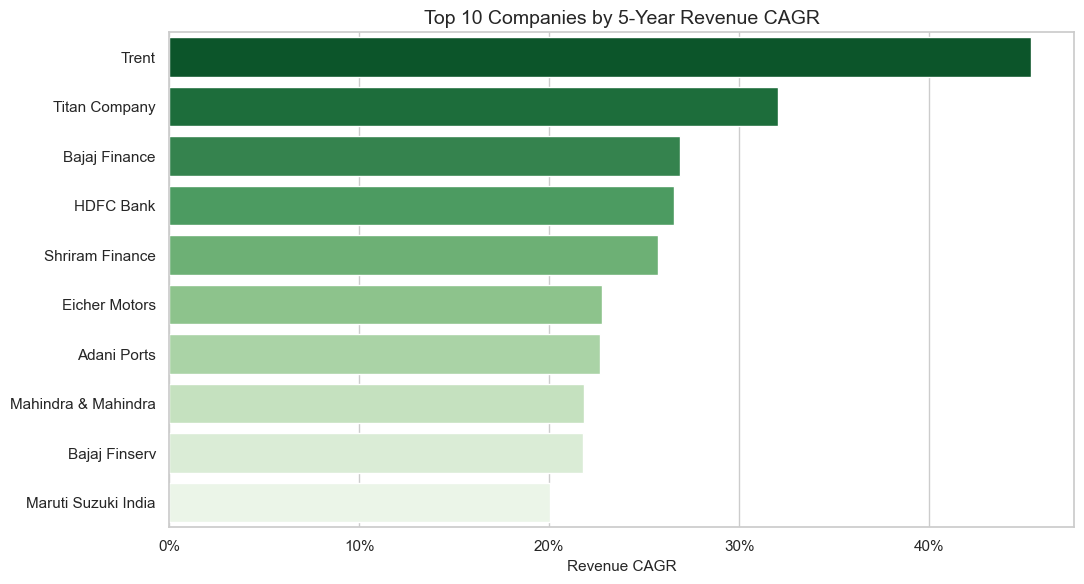


### Observation
**Trent** has the highest five-year revenue CAGR in the panel at approximately **45.3%**.

### Business Interpretation
High revenue CAGR signals expansion momentum, but it must be cross-checked against margin stability and cash-flow conversion.

### Recommendation
Prioritize growth companies that also maintain positive operating margins, improving ROE, and sustainable operating cash flow.


In [10]:
growth = (
    df.groupby(["ticker", "company", "sector"])
    .agg(start_revenue=("revenue_cr", "first"), end_revenue=("revenue_cr", "last"),
         start_profit=("net_profit_cr", "first"), end_profit=("net_profit_cr", "last"))
    .reset_index()
)
years = df["financial_year"].nunique() - 1
growth["revenue_cagr"] = (growth["end_revenue"] / growth["start_revenue"]) ** (1 / years) - 1
growth["profit_cagr"] = np.where(
    (growth["start_profit"] > 0) & (growth["end_profit"] > 0),
    (growth["end_profit"] / growth["start_profit"]) ** (1 / years) - 1,
    np.nan
)

top_growth = growth.replace([np.inf, -np.inf], np.nan).dropna(subset=["revenue_cagr"]).nlargest(10, "revenue_cagr")
ax = sns.barplot(data=top_growth, x="revenue_cagr", y="company", palette="Greens_r")
ax.set_title("Top 10 Companies by 5-Year Revenue CAGR")
ax.set_xlabel("Revenue CAGR")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

best_growth = top_growth.iloc[0]
display(Markdown(f'''
### Observation
**{best_growth['company']}** has the highest five-year revenue CAGR in the panel at approximately **{best_growth['revenue_cagr']:.1%}**.

### Business Interpretation
High revenue CAGR signals expansion momentum, but it must be cross-checked against margin stability and cash-flow conversion.

### Recommendation
Prioritize growth companies that also maintain positive operating margins, improving ROE, and sustainable operating cash flow.
'''))

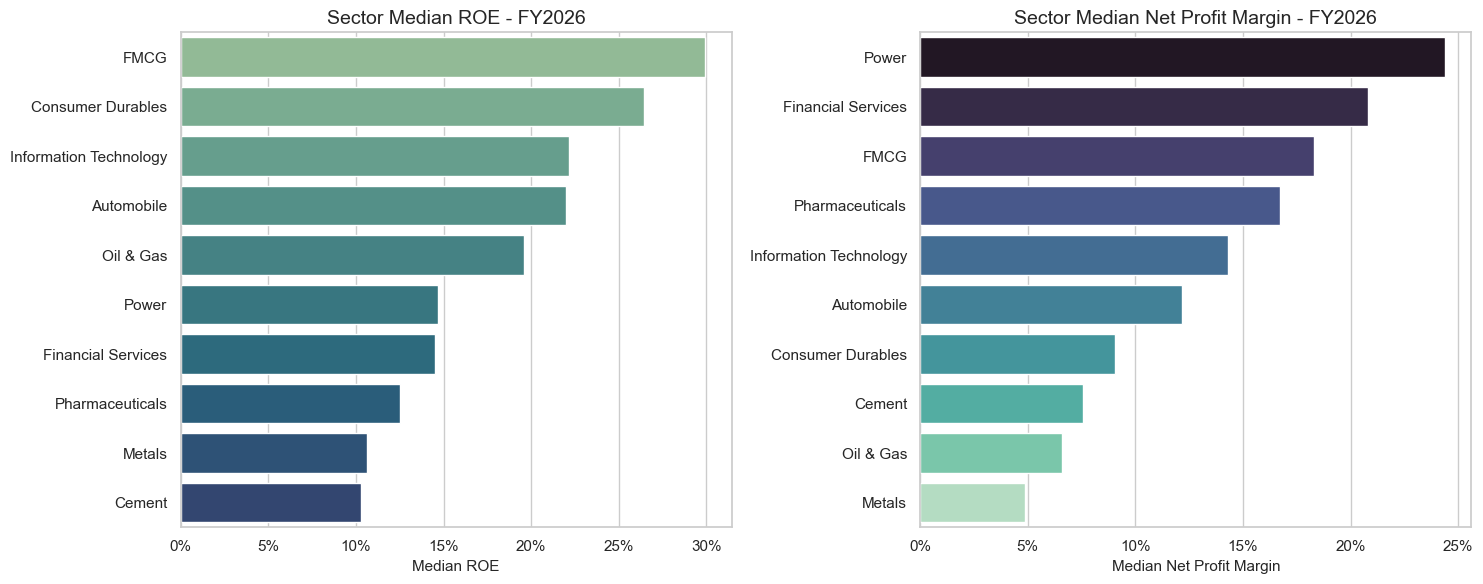


### Observation
Among sectors with at least two companies, **FMCG** records the highest median ROE in FY2026, at approximately **29.9%**.

### Business Interpretation
Sector-level profitability is shaped by business model economics: pricing power, asset intensity, working capital cycles, and leverage structures.

### Recommendation
Benchmark companies against sector peers before making cross-sector conclusions. A lower-margin company may still be strong if its sector is structurally asset-heavy.


In [11]:
sector_perf = (
    latest.groupby("sector")
    .agg(
        companies=("ticker", "nunique"),
        median_revenue=("revenue_cr", "median"),
        median_net_margin=("net_profit_margin", "median"),
        median_roe=("roe", "median"),
        median_debt_to_equity=("debt_to_equity", "median"),
        median_asset_turnover=("asset_turnover", "median")
    )
    .query("companies >= 2")
    .sort_values("median_roe", ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=sector_perf, x="median_roe", y="sector", ax=axes[0], palette="crest")
axes[0].set_title(f"Sector Median ROE - FY{latest_year}")
axes[0].set_xlabel("Median ROE")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

sns.barplot(data=sector_perf.sort_values("median_net_margin", ascending=False), x="median_net_margin", y="sector", ax=axes[1], palette="mako")
axes[1].set_title(f"Sector Median Net Profit Margin - FY{latest_year}")
axes[1].set_xlabel("Median Net Profit Margin")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

best_sector = sector_perf.iloc[0]
display(Markdown(f'''
### Observation
Among sectors with at least two companies, **{best_sector['sector']}** records the highest median ROE in FY{latest_year}, at approximately **{best_sector['median_roe']:.1%}**.

### Business Interpretation
Sector-level profitability is shaped by business model economics: pricing power, asset intensity, working capital cycles, and leverage structures.

### Recommendation
Benchmark companies against sector peers before making cross-sector conclusions. A lower-margin company may still be strong if its sector is structurally asset-heavy.
'''))

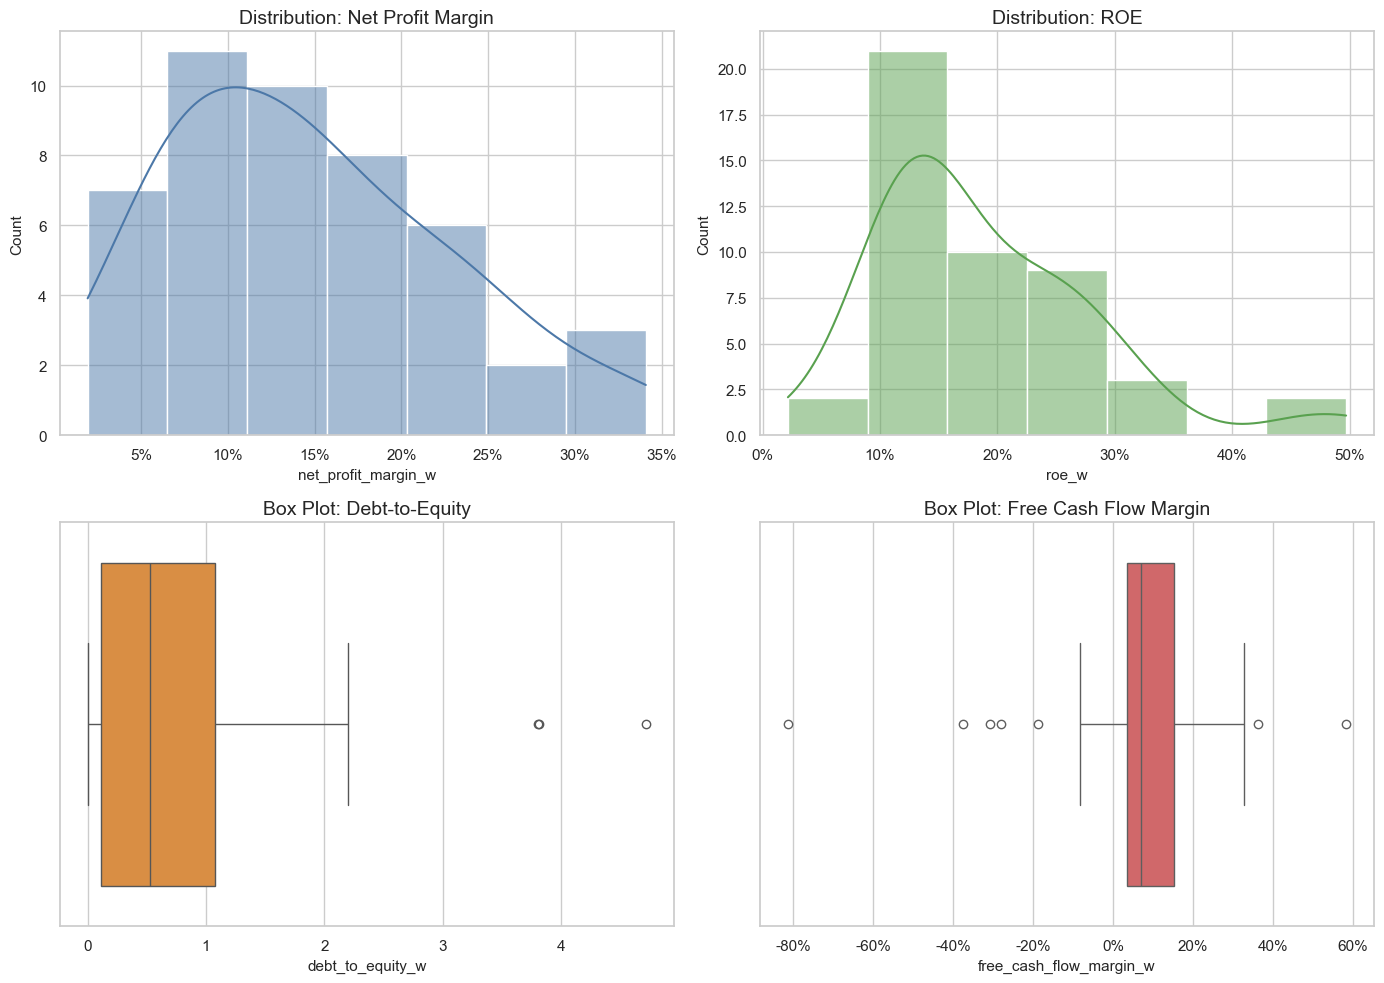


### Observation
Profitability and leverage ratios show visible dispersion, with a few companies sitting far away from the middle of the panel.

### Business Interpretation
Outliers are analytically valuable. They may indicate exceptional economics, temporary distress, sector-specific accounting, or capital-structure differences.

### Recommendation
Treat outliers as due-diligence candidates. Do not remove them from business interpretation; instead, separate structural outliers from data-quality issues.


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_data = latest.copy()

sns.histplot(plot_data["net_profit_margin_w"].dropna(), kde=True, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Distribution: Net Profit Margin")
axes[0, 0].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

sns.histplot(plot_data["roe_w"].dropna(), kde=True, ax=axes[0, 1], color="#59A14F")
axes[0, 1].set_title("Distribution: ROE")
axes[0, 1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

sns.boxplot(data=plot_data, x="debt_to_equity_w", ax=axes[1, 0], color="#F28E2B")
axes[1, 0].set_title("Box Plot: Debt-to-Equity")

sns.boxplot(data=plot_data, x="free_cash_flow_margin_w", ax=axes[1, 1], color="#E15759")
axes[1, 1].set_title("Box Plot: Free Cash Flow Margin")
axes[1, 1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

plt.tight_layout()
plt.show()

display(Markdown(f'''
### Observation
Profitability and leverage ratios show visible dispersion, with a few companies sitting far away from the middle of the panel.

### Business Interpretation
Outliers are analytically valuable. They may indicate exceptional economics, temporary distress, sector-specific accounting, or capital-structure differences.

### Recommendation
Treat outliers as due-diligence candidates. Do not remove them from business interpretation; instead, separate structural outliers from data-quality issues.
'''))

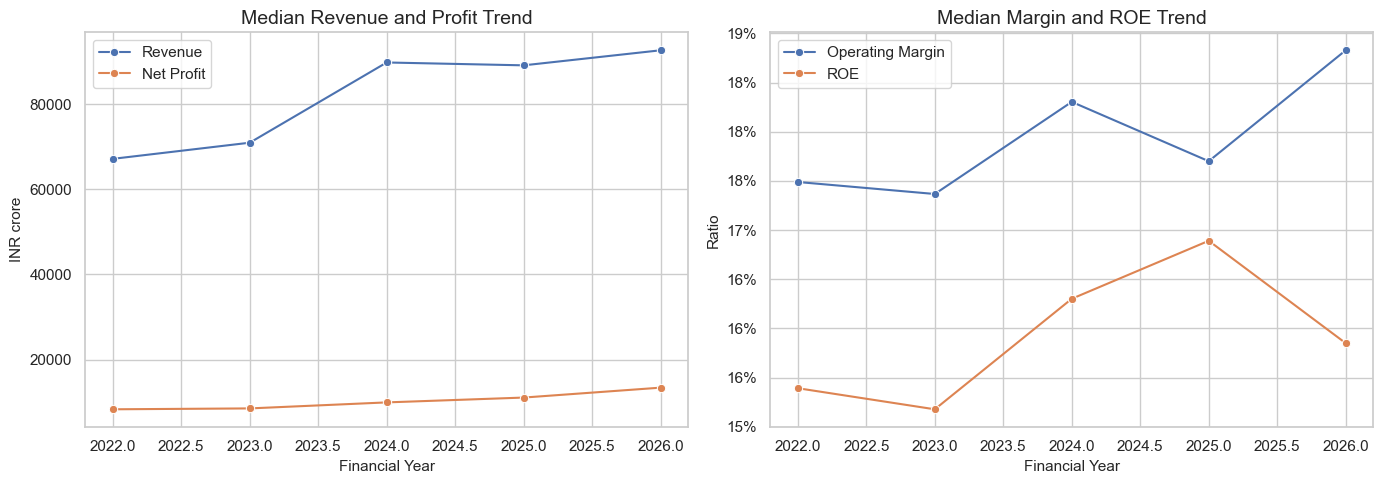


### Observation
The median company shows revenue and profit expansion over the five-year window, while profitability ratios move less uniformly than absolute scale.

### Business Interpretation
Top-line growth is not enough. Margin and ROE trends reveal whether growth is creating shareholder value or merely increasing business volume.

### Recommendation
For interview and consulting discussions, frame performance as a combination of growth quality, capital efficiency, and cash-flow reliability.


In [13]:
trend = df.groupby("financial_year").agg(
    median_revenue=("revenue_cr", "median"),
    median_profit=("net_profit_cr", "median"),
    median_operating_margin=("operating_margin", "median"),
    median_roe=("roe", "median")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=trend, x="financial_year", y="median_revenue", marker="o", ax=axes[0], label="Revenue")
sns.lineplot(data=trend, x="financial_year", y="median_profit", marker="o", ax=axes[0], label="Net Profit")
axes[0].set_title("Median Revenue and Profit Trend")
axes[0].set_xlabel("Financial Year")
axes[0].set_ylabel("INR crore")

sns.lineplot(data=trend, x="financial_year", y="median_operating_margin", marker="o", ax=axes[1], label="Operating Margin")
sns.lineplot(data=trend, x="financial_year", y="median_roe", marker="o", ax=axes[1], label="ROE")
axes[1].set_title("Median Margin and ROE Trend")
axes[1].set_xlabel("Financial Year")
axes[1].set_ylabel("Ratio")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

plt.tight_layout()
plt.show()

display(Markdown(f'''
### Observation
The median company shows revenue and profit expansion over the five-year window, while profitability ratios move less uniformly than absolute scale.

### Business Interpretation
Top-line growth is not enough. Margin and ROE trends reveal whether growth is creating shareholder value or merely increasing business volume.

### Recommendation
For interview and consulting discussions, frame performance as a combination of growth quality, capital efficiency, and cash-flow reliability.
'''))

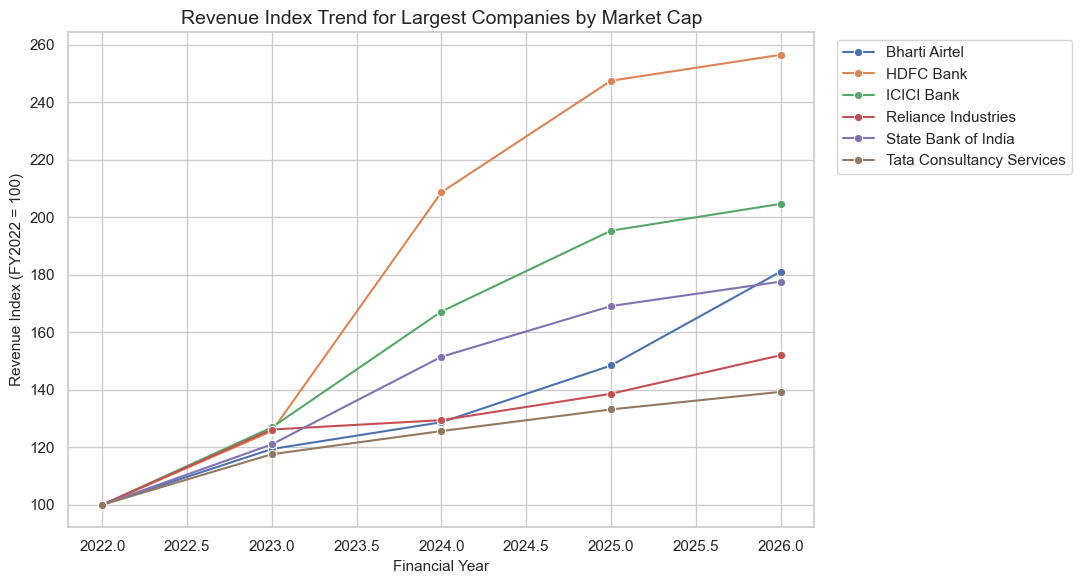


### Observation
Indexed revenue trends show how large companies differ in growth pace even when starting from a common baseline.

### Business Interpretation
Market leaders do not grow at the same rate. Mature companies may offer stability, while smaller or transforming companies may deliver faster expansion.

### Recommendation
Use indexed trends for management presentations because they communicate relative momentum more clearly than raw revenue bars.


In [14]:
selected = latest.nlargest(6, "market_cap_cr")["ticker"].tolist()
indexed = df[df["ticker"].isin(selected)].copy()
indexed["revenue_index"] = indexed.groupby("ticker")["revenue_cr"].transform(lambda s: s / s.iloc[0] * 100)

ax = sns.lineplot(data=indexed, x="financial_year", y="revenue_index", hue="company", marker="o")
ax.set_title("Revenue Index Trend for Largest Companies by Market Cap")
ax.set_xlabel("Financial Year")
ax.set_ylabel("Revenue Index (FY2022 = 100)")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(Markdown(f'''
### Observation
Indexed revenue trends show how large companies differ in growth pace even when starting from a common baseline.

### Business Interpretation
Market leaders do not grow at the same rate. Mature companies may offer stability, while smaller or transforming companies may deliver faster expansion.

### Recommendation
Use indexed trends for management presentations because they communicate relative momentum more clearly than raw revenue bars.
'''))

## 7. Financial Ratio Analysis

In [15]:
ratio_summary = latest[[
    "gross_margin", "operating_margin", "net_profit_margin", "roa", "roe",
    "debt_to_equity", "current_ratio", "quick_ratio", "asset_turnover",
    "interest_coverage", "ebitda_margin", "free_cash_flow_margin", "cfo_to_profit"
]].describe(percentiles=[0.25, 0.5, 0.75]).T
ratio_summary

,count,mean,std,min,25%,50%,75%,max
gross_margin,36.00,0.43,0.19,0.00,0.30,0.42,0.49,0.89
operating_margin,47.00,0.19,0.18,-0.20,0.13,0.19,0.25,0.75
net_profit_margin,47.00,0.15,0.08,0.02,0.08,0.13,0.20,0.34
roa,47.00,0.09,0.07,0.00,0.04,0.07,0.12,0.27
roe,47.00,0.19,0.09,0.01,0.12,0.16,0.25,0.50
debt_to_equity,47.00,0.82,1.10,0.00,0.11,0.53,1.08,5.52
current_ratio,37.00,1.62,0.94,0.52,1.06,1.28,1.91,5.43
quick_ratio,37.00,1.24,0.75,0.20,0.65,1.03,1.64,3.50
asset_turnover,47.00,0.69,0.50,0.06,0.28,0.63,0.94,1.97
interest_coverage,46.00,31.04,55.91,-0.45,3.30,8.73,33.21,321.25


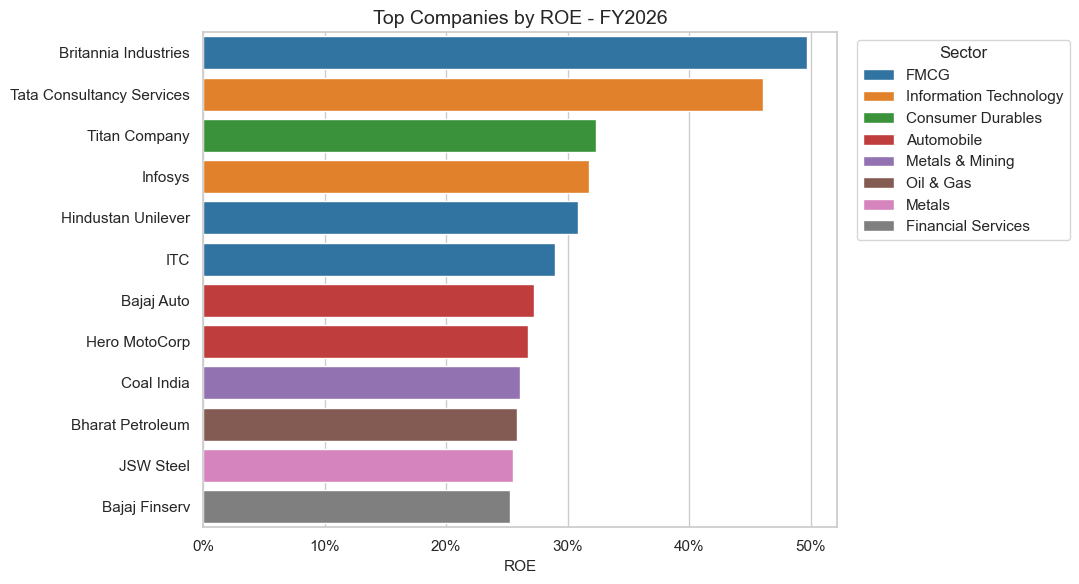


### Observation
**Britannia Industries** reports one of the strongest FY2026 ROE outcomes in the panel at approximately **49.7%**.

### Business Interpretation
High ROE can come from strong profitability, efficient asset usage, or high leverage. It should be decomposed before being treated as purely positive.

### Recommendation
Pair ROE with debt-to-equity and cash conversion. Strong ROE with weak cash flow or excessive leverage deserves risk review.


In [16]:
ratio_view = latest[["company", "sector", "operating_margin", "net_profit_margin", "roa", "roe", "debt_to_equity", "asset_turnover", "free_cash_flow_margin"]].copy()
ratio_view = ratio_view.sort_values("roe", ascending=False).head(12)

ax = sns.barplot(data=ratio_view, y="company", x="roe", hue="sector", dodge=False, palette="tab10")
ax.set_title(f"Top Companies by ROE - FY{latest_year}")
ax.set_xlabel("ROE")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.legend(title="Sector", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

top_roe = ratio_view.iloc[0]
display(Markdown(f'''
### Observation
**{top_roe['company']}** reports one of the strongest FY{latest_year} ROE outcomes in the panel at approximately **{top_roe['roe']:.1%}**.

### Business Interpretation
High ROE can come from strong profitability, efficient asset usage, or high leverage. It should be decomposed before being treated as purely positive.

### Recommendation
Pair ROE with debt-to-equity and cash conversion. Strong ROE with weak cash flow or excessive leverage deserves risk review.
'''))

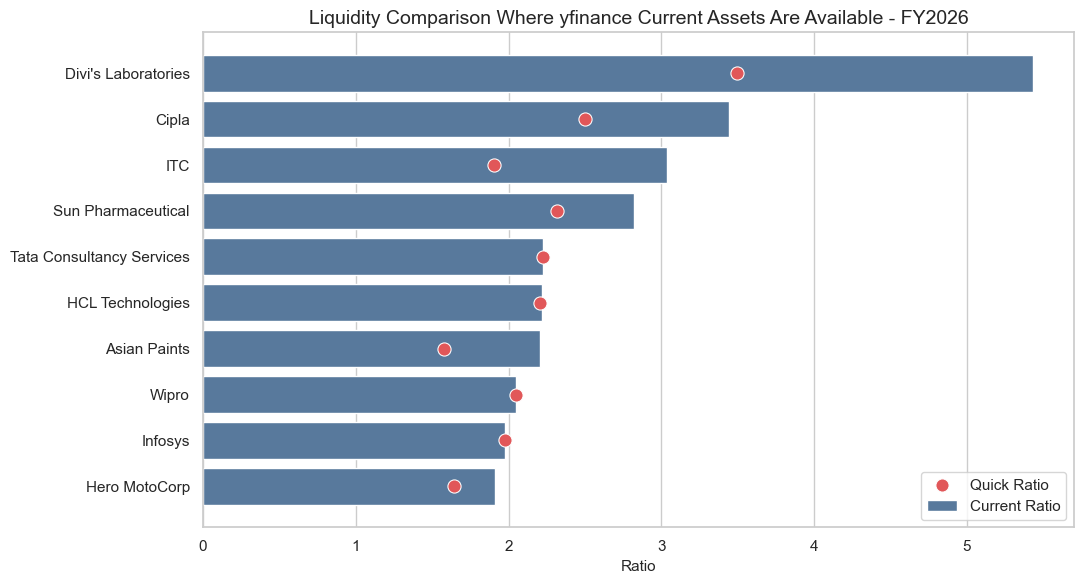


### Observation
Current and quick ratios are available for **37 companies** in FY2026; they are not forced for banks or insurers where this comparison is less meaningful.

### Business Interpretation
Higher liquidity provides short-term resilience, but very high current ratios can also indicate idle working capital or slower inventory/debtor cycles.

### Recommendation
Use liquidity ratios mainly for non-financial companies, and interpret them alongside cash conversion and sector working-capital norms.


In [17]:
liquidity = latest.dropna(subset=["current_ratio", "quick_ratio"]).copy()
liquidity_top = liquidity.nlargest(10, "current_ratio")

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=liquidity_top, y="company", x="current_ratio", color="#4C78A8", label="Current Ratio", ax=ax)
sns.scatterplot(data=liquidity_top, y="company", x="quick_ratio", color="#E15759", s=90, label="Quick Ratio", ax=ax)
ax.set_title(f"Liquidity Comparison Where yfinance Current Assets Are Available - FY{latest_year}")
ax.set_xlabel("Ratio")
ax.set_ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown(f'''
### Observation
Current and quick ratios are available for **{liquidity['ticker'].nunique()} companies** in FY{latest_year}; they are not forced for banks or insurers where this comparison is less meaningful.

### Business Interpretation
Higher liquidity provides short-term resilience, but very high current ratios can also indicate idle working capital or slower inventory/debtor cycles.

### Recommendation
Use liquidity ratios mainly for non-financial companies, and interpret them alongside cash conversion and sector working-capital norms.
'''))

## 8. Statistical Analysis

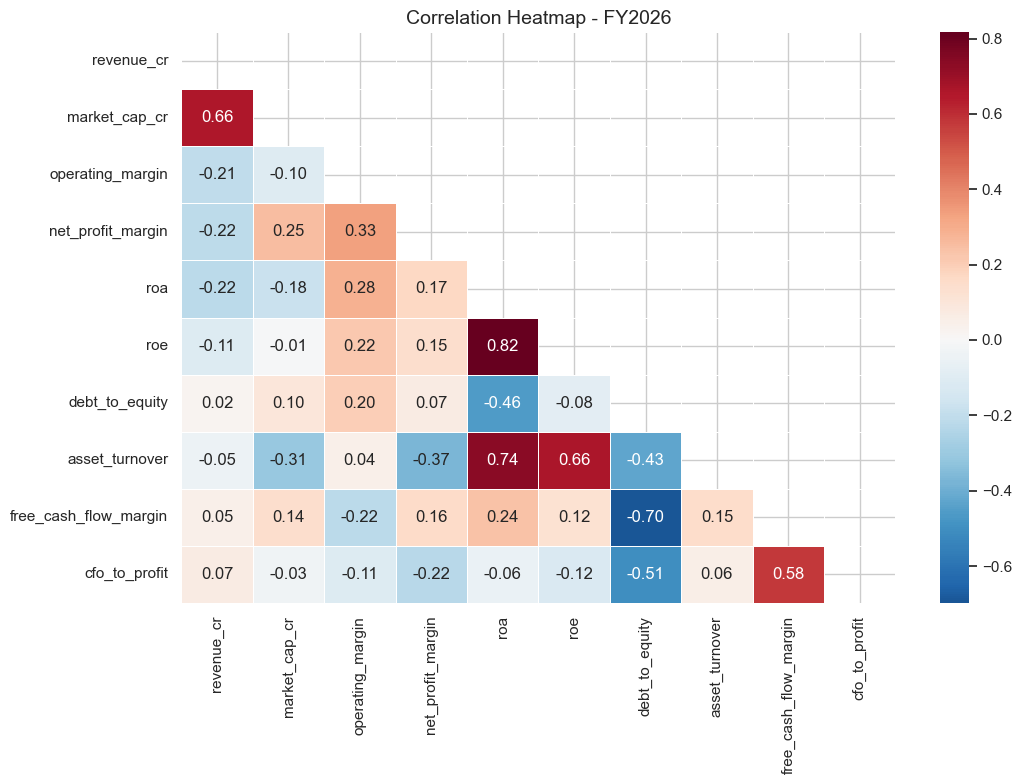


### Observation
The correlation heatmap highlights the strongest pairwise relationship among the selected metrics: **roe** and **roa**.

### Business Interpretation
Correlations help identify patterns, but they do not prove causality. Financial ratios are often jointly influenced by sector economics and accounting structure.

### Recommendation
Use correlation as a hypothesis-generation tool, then validate with sector splits, scatter plots, and business logic.


In [18]:
correlation_cols = [
    "revenue_cr", "market_cap_cr", "operating_margin", "net_profit_margin", "roa", "roe",
    "debt_to_equity", "asset_turnover", "free_cash_flow_margin", "cfo_to_profit"
]
corr_data = latest[correlation_cols].replace([np.inf, -np.inf], np.nan)
corr = corr_data.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5)
plt.title(f"Correlation Heatmap - FY{latest_year}")
plt.tight_layout()
plt.show()

strongest = corr.where(~np.eye(corr.shape[0], dtype=bool)).stack().abs().sort_values(ascending=False).index[0]
display(Markdown(f'''
### Observation
The correlation heatmap highlights the strongest pairwise relationship among the selected metrics: **{strongest[0]}** and **{strongest[1]}**.

### Business Interpretation
Correlations help identify patterns, but they do not prove causality. Financial ratios are often jointly influenced by sector economics and accounting structure.

### Recommendation
Use correlation as a hypothesis-generation tool, then validate with sector splits, scatter plots, and business logic.
'''))

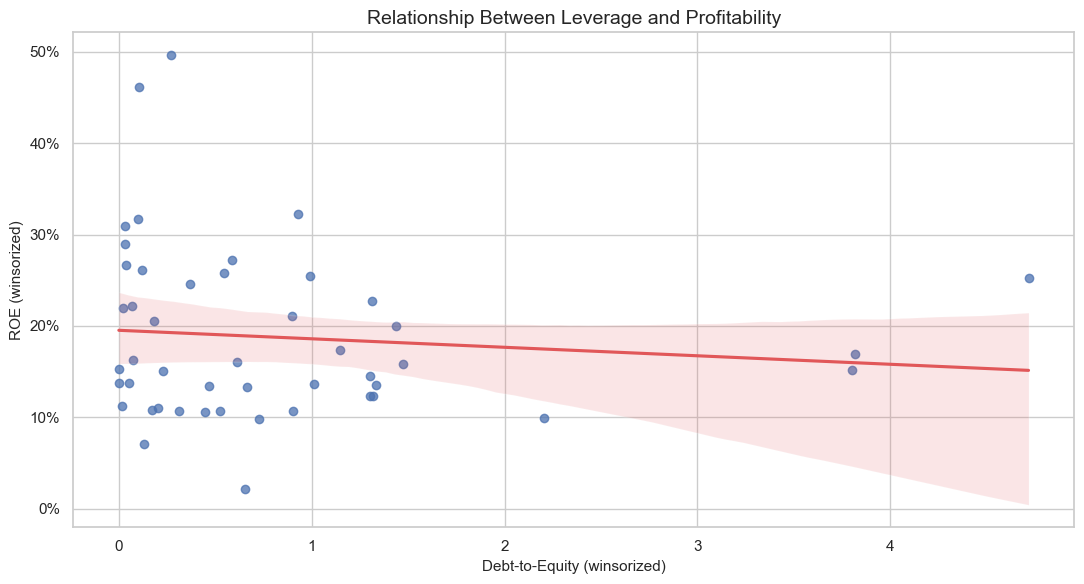


### Observation
The leverage-profitability regression has **R = -0.10** and **p-value = 0.497**.

### Business Interpretation
The statistical relationship is not statistically strong at the 5% level in this cross-section. Leverage may amplify returns, but it can also reflect sector structure rather than management quality.

### Recommendation
Avoid using debt-to-equity as a standalone risk signal. Interpret leverage relative to sector norms, interest coverage, and operating cash-flow stability.


In [19]:
scatter_data = latest.dropna(subset=["debt_to_equity", "roe"]).copy()
slope, intercept, r_value, p_value, std_err = stats.linregress(scatter_data["debt_to_equity_w"], scatter_data["roe_w"])

ax = sns.regplot(data=scatter_data, x="debt_to_equity_w", y="roe_w", scatter_kws={"alpha": 0.75}, line_kws={"color": "#E15759"})
ax.set_title("Relationship Between Leverage and Profitability")
ax.set_xlabel("Debt-to-Equity (winsorized)")
ax.set_ylabel("ROE (winsorized)")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

display(Markdown(f'''
### Observation
The leverage-profitability regression has **R = {r_value:.2f}** and **p-value = {p_value:.3f}**.

### Business Interpretation
The statistical relationship is {'statistically meaningful at the 5% level' if p_value < 0.05 else 'not statistically strong at the 5% level'} in this cross-section. Leverage may amplify returns, but it can also reflect sector structure rather than management quality.

### Recommendation
Avoid using debt-to-equity as a standalone risk signal. Interpret leverage relative to sector norms, interest coverage, and operating cash-flow stability.
'''))

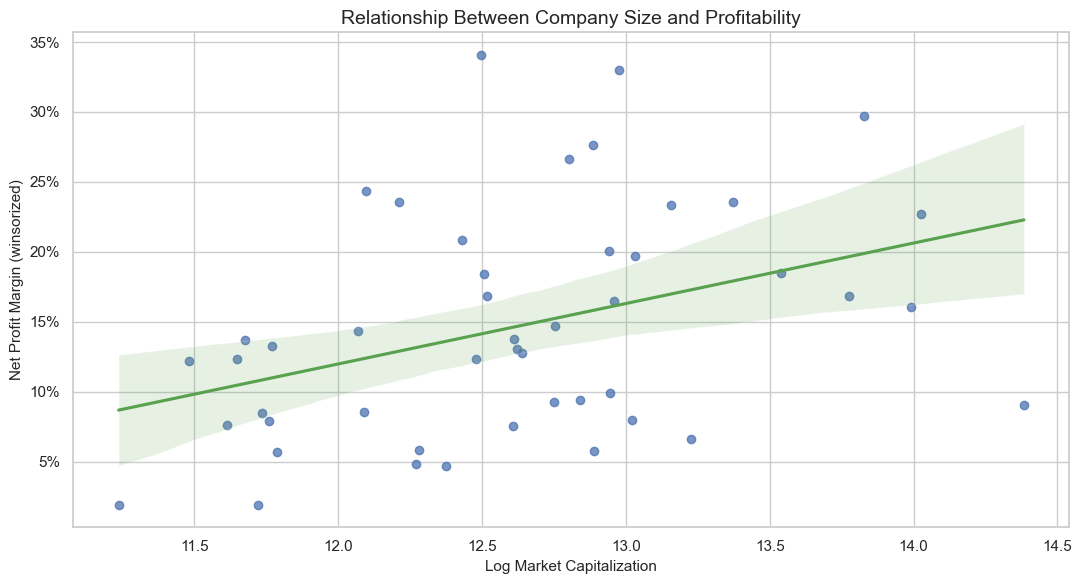


### Observation
The size-profitability regression has **R = 0.39** and **p-value = 0.007**.

### Business Interpretation
Scale alone shows a statistically meaningful association with profitability in this panel. Competitive positioning and sector economics still matter.

### Recommendation
For strategic benchmarking, combine market-cap scale with ROA, ROE, operating margin, and cash conversion rather than treating size as a performance proxy.


In [20]:
size_data = latest.dropna(subset=["market_cap_cr", "net_profit_margin"]).copy()
size_data = size_data[size_data["market_cap_cr"] > 0]
size_data["log_market_cap"] = np.log(size_data["market_cap_cr"])
slope2, intercept2, r_value2, p_value2, std_err2 = stats.linregress(size_data["log_market_cap"], size_data["net_profit_margin_w"])

ax = sns.regplot(data=size_data, x="log_market_cap", y="net_profit_margin_w", scatter_kws={"alpha": 0.75}, line_kws={"color": "#59A14F"})
ax.set_title("Relationship Between Company Size and Profitability")
ax.set_xlabel("Log Market Capitalization")
ax.set_ylabel("Net Profit Margin (winsorized)")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

display(Markdown(f'''
### Observation
The size-profitability regression has **R = {r_value2:.2f}** and **p-value = {p_value2:.3f}**.

### Business Interpretation
Scale alone {'shows a statistically meaningful association with profitability' if p_value2 < 0.05 else 'does not fully explain profitability'} in this panel. Competitive positioning and sector economics still matter.

### Recommendation
For strategic benchmarking, combine market-cap scale with ROA, ROE, operating margin, and cash conversion rather than treating size as a performance proxy.
'''))

In [21]:
def sector_bucket(sector):
    high_quality = {"Information Technology", "FMCG", "Pharmaceuticals", "Consumer Durables", "Healthcare"}
    cyclical = {"Metals", "Metals & Mining", "Oil & Gas", "Power", "Cement", "Construction", "Automobile"}
    if sector in high_quality:
        return "Asset-light / defensive"
    if sector in cyclical:
        return "Cyclical / asset-heavy"
    return "Other"

hyp = latest.copy()
hyp["sector_bucket"] = hyp["sector"].apply(sector_bucket)
group_a = hyp[hyp["sector_bucket"] == "Asset-light / defensive"]["net_profit_margin"].dropna()
group_b = hyp[hyp["sector_bucket"] == "Cyclical / asset-heavy"]["net_profit_margin"].dropna()
t_stat, t_p = stats.ttest_ind(group_a, group_b, equal_var=False)

display(Markdown(f'''
### Hypothesis Test: Do asset-light/defensive sectors have higher net margins than cyclical/asset-heavy sectors?

**Null hypothesis:** average net profit margin is the same across the two sector buckets.  
**Alternative hypothesis:** average net profit margin differs across the two buckets.

- Asset-light/defensive mean margin: **{group_a.mean():.1%}**
- Cyclical/asset-heavy mean margin: **{group_b.mean():.1%}**
- Welch t-statistic: **{t_stat:.2f}**
- p-value: **{t_p:.3f}**

### Business Interpretation
The test {'supports a statistically meaningful difference in margins' if t_p < 0.05 else 'does not provide strong statistical evidence of a margin difference'} at the 5% level.

### Recommendation
Use sector economics as the starting point for margin benchmarking. Comparing an IT firm with a metals or oil business without sector adjustment can lead to misleading conclusions.
'''))


### Hypothesis Test: Do asset-light/defensive sectors have higher net margins than cyclical/asset-heavy sectors?

**Null hypothesis:** average net profit margin is the same across the two sector buckets.  
**Alternative hypothesis:** average net profit margin differs across the two buckets.

- Asset-light/defensive mean margin: **14.9%**
- Cyclical/asset-heavy mean margin: **12.2%**
- Welch t-statistic: **1.04**
- p-value: **0.307**

### Business Interpretation
The test does not provide strong statistical evidence of a margin difference at the 5% level.

### Recommendation
Use sector economics as the starting point for margin benchmarking. Comparing an IT firm with a metals or oil business without sector adjustment can lead to misleading conclusions.


In [22]:
cluster_features = ["operating_margin", "roe", "debt_to_equity", "asset_turnover", "free_cash_flow_margin", "revenue_cagr"]
cluster_input = latest.merge(growth[["ticker", "revenue_cagr"]], on="ticker", how="left")
cluster_input = cluster_input.dropna(subset=cluster_features).copy()

X = cluster_input[cluster_features].replace([np.inf, -np.inf], np.nan).dropna()
cluster_input = cluster_input.loc[X.index].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
cluster_input["cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = cluster_input.groupby("cluster")[cluster_features].median().round(3)
cluster_profile

,operating_margin,roe,debt_to_equity,asset_turnover,free_cash_flow_margin,revenue_cagr
cluster,,,,,,
0,-0.13,0.12,0.65,0.07,0.23,0.18
1,0.19,0.14,0.47,0.59,0.07,0.10
2,0.33,0.17,3.82,0.15,-0.38,0.26
3,0.20,0.27,0.10,1.20,0.13,0.12


In [23]:
cluster_labels = {}
for cluster_id, row in cluster_profile.iterrows():
    if row["operating_margin"] > cluster_profile["operating_margin"].median() and row["roe"] > cluster_profile["roe"].median():
        label = "High profitability compounders"
    elif row["revenue_cagr"] > cluster_profile["revenue_cagr"].median() and row["asset_turnover"] > cluster_profile["asset_turnover"].median():
        label = "Growth and efficiency leaders"
    elif row["debt_to_equity"] > cluster_profile["debt_to_equity"].median():
        label = "Leveraged / capital intensive"
    else:
        label = "Steady but lower-return"
    cluster_labels[cluster_id] = label

cluster_input["cluster_label"] = cluster_input["cluster"].map(cluster_labels)
display(cluster_input[["company", "sector", "cluster_label", "operating_margin", "roe", "debt_to_equity", "revenue_cagr"]].sort_values(["cluster_label", "company"]).head(20))

display(Markdown('''
### Observation
Clustering separates companies into performance archetypes based on profitability, leverage, asset efficiency, cash generation, and growth.

### Business Interpretation
This converts ratio analysis into a management-friendly segmentation. A company can be discussed as a compounder, growth leader, leveraged business, or lower-return operator.

### Recommendation
Use the clusters as a screening layer before deeper company research. They are not final investment calls, but they help prioritize where to investigate.
'''))

,company,sector,cluster_label,operating_margin,roe,debt_to_equity,revenue_cagr
2,Apollo Hospitals,Healthcare,High profitability compounders,0.15,0.21,0.90,0.15
5,Bajaj Auto,Automobile,High profitability compounders,0.21,0.27,0.58,0.17
7,Bajaj Finance,Financial Services,High profitability compounders,0.33,0.17,3.82,0.27
6,Bajaj Finserv,Financial Services,High profitability compounders,0.38,0.25,5.52,0.22
9,Bharat Petroleum,Oil & Gas,High profitability compounders,0.09,0.26,0.54,0.07
10,Britannia Industries,FMCG,High profitability compounders,0.18,0.50,0.27,0.08
15,Eicher Motors,Automobile,High profitability compounders,0.25,0.22,0.02,0.23
17,HCL Technologies,Information Technology,High profitability compounders,0.21,0.22,0.07,0.11
20,Hero MotoCorp,Automobile,High profitability compounders,0.15,0.27,0.04,0.13
22,Hindustan Unilever,FMCG,High profitability compounders,0.23,0.31,0.03,0.05



### Observation
Clustering separates companies into performance archetypes based on profitability, leverage, asset efficiency, cash generation, and growth.

### Business Interpretation
This converts ratio analysis into a management-friendly segmentation. A company can be discussed as a compounder, growth leader, leveraged business, or lower-return operator.

### Recommendation
Use the clusters as a screening layer before deeper company research. They are not final investment calls, but they help prioritize where to investigate.


## 9. Top-Performing and Underperforming Companies

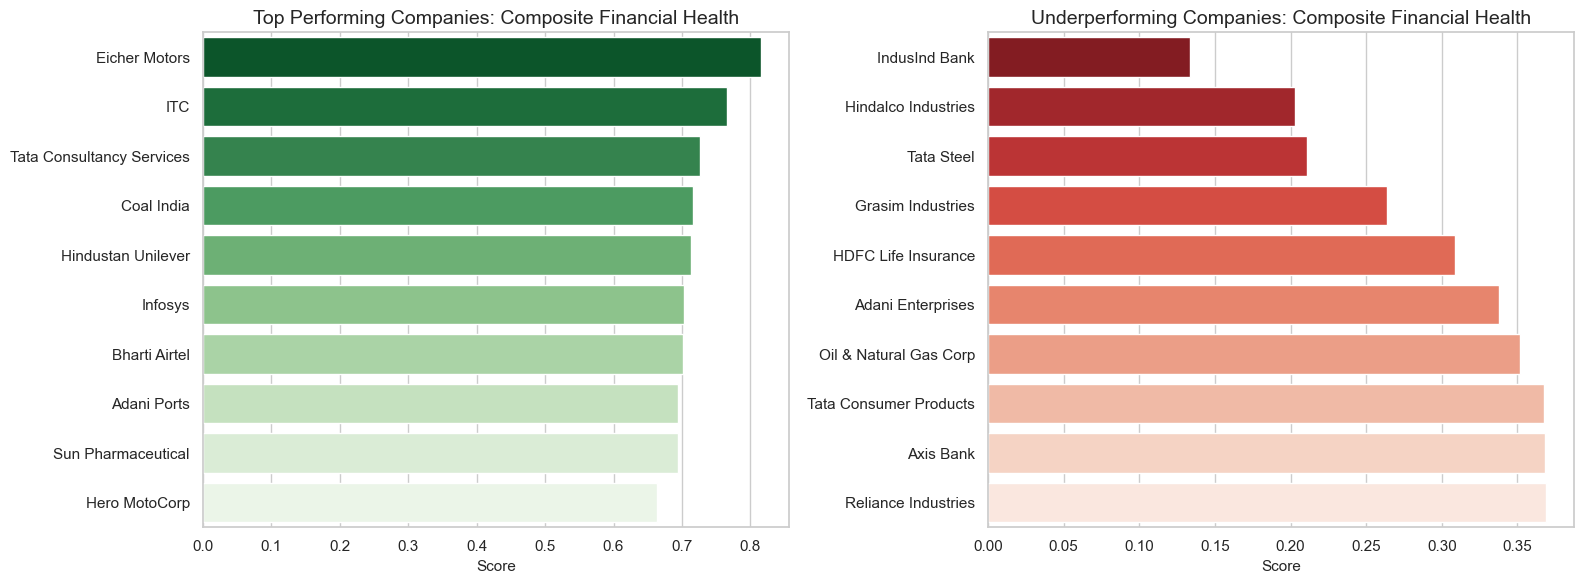


### Observation
The strongest composite score belongs to **Eicher Motors**, while **IndusInd Bank** appears at the weaker end of the scorecard.

### Business Interpretation
The score rewards balanced financial performance: margins, returns, growth, cash generation, and lower leverage. It penalizes companies that rely on scale without adequate profitability or cash conversion.

### Recommendation
Use the scorecard as a portfolio screening and management benchmarking tool. Follow up with company-specific qualitative research before final decisions.


In [24]:
score_df = latest.merge(growth[["ticker", "revenue_cagr", "profit_cagr"]], on="ticker", how="left").copy()
score_metrics = {
    "operating_margin": 0.16,
    "net_profit_margin": 0.14,
    "roe": 0.16,
    "roa": 0.12,
    "revenue_cagr": 0.12,
    "profit_cagr": 0.10,
    "free_cash_flow_margin": 0.10,
    "debt_to_equity": -0.10,
}

for metric, weight in score_metrics.items():
    series = score_df[metric].replace([np.inf, -np.inf], np.nan)
    rank = series.rank(pct=True)
    if weight < 0:
        rank = 1 - rank
    score_df[metric + "_score"] = rank * abs(weight)

score_cols = [m + "_score" for m in score_metrics]
score_df["financial_health_score"] = score_df[score_cols].sum(axis=1) / sum(abs(w) for w in score_metrics.values())

top_companies = score_df.nlargest(10, "financial_health_score")
bottom_companies = score_df.nsmallest(10, "financial_health_score")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top_companies, y="company", x="financial_health_score", ax=axes[0], palette="Greens_r")
axes[0].set_title("Top Performing Companies: Composite Financial Health")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("")

sns.barplot(data=bottom_companies, y="company", x="financial_health_score", ax=axes[1], palette="Reds_r")
axes[1].set_title("Underperforming Companies: Composite Financial Health")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

display(Markdown(f'''
### Observation
The strongest composite score belongs to **{top_companies.iloc[0]['company']}**, while **{bottom_companies.iloc[0]['company']}** appears at the weaker end of the scorecard.

### Business Interpretation
The score rewards balanced financial performance: margins, returns, growth, cash generation, and lower leverage. It penalizes companies that rely on scale without adequate profitability or cash conversion.

### Recommendation
Use the scorecard as a portfolio screening and management benchmarking tool. Follow up with company-specific qualitative research before final decisions.
'''))

## 10. Business Insights

In [25]:
insights = []

def add_insight(title, observation, interpretation, implication):
    insights.append({
        "Insight": title,
        "Observation": observation,
        "Interpretation": interpretation,
        "Business implication": implication
    })

best_margin_sector = sector_perf.sort_values("median_net_margin", ascending=False).iloc[0]
best_roe_sector = sector_perf.sort_values("median_roe", ascending=False).iloc[0]
cash_leader = latest.sort_values("cfo_to_profit", ascending=False).dropna(subset=["cfo_to_profit"]).iloc[0]
low_leverage = latest.sort_values("debt_to_equity").dropna(subset=["debt_to_equity"]).iloc[0]
highest_liquidity = liquidity.sort_values("current_ratio", ascending=False).iloc[0] if len(liquidity) else None
growth_leader = top_growth.iloc[0]
profit_growth_leader = growth.dropna(subset=["profit_cagr"]).sort_values("profit_cagr", ascending=False).iloc[0]
fcf_leader = latest.dropna(subset=["free_cash_flow_margin"]).sort_values("free_cash_flow_margin", ascending=False).iloc[0]
asset_turnover_leader = latest.sort_values("asset_turnover", ascending=False).iloc[0]
risk_company = bottom_companies.iloc[0]

add_insight(
    "Sector profitability is uneven",
    f"{best_margin_sector['sector']} has the highest median net profit margin among sectors with at least two companies.",
    "Profitability differences reflect sector economics, not only management execution.",
    "Analysts should compare firms with sector peers before ranking them across the full market."
)
add_insight(
    "Capital efficiency leaders stand out",
    f"{best_roe_sector['sector']} records the strongest median ROE in FY{latest_year}.",
    "High ROE indicates either strong profit generation, efficient capital use, or leverage effects.",
    "Decompose ROE using leverage and margin before calling the sector structurally superior."
)
add_insight(
    "Growth quality needs validation",
    f"{growth_leader['company']} leads the panel on revenue CAGR.",
    "Revenue growth can come from volume, pricing, acquisitions, or cyclical recovery.",
    "Prioritize high-growth companies only when margins and cash flow confirm quality of growth."
)
add_insight(
    "Profit momentum is concentrated",
    f"{profit_growth_leader['company']} ranks highest on positive profit CAGR among companies with comparable positive base profit.",
    "Profit CAGR can be volatile when base-year profit is low.",
    "Use profit growth with base-year normalization and operating margin trend."
)
add_insight(
    "Cash conversion is a key differentiator",
    f"{cash_leader['company']} shows one of the strongest operating-cash-flow-to-profit ratios.",
    "Cash-backed earnings are generally higher quality than accounting profit alone.",
    "Companies with weak cash conversion require working-capital and accrual quality review."
)
add_insight(
    "Balance sheet conservatism varies",
    f"{low_leverage['company']} has among the lowest debt-to-equity ratios in FY{latest_year}.",
    "Low leverage can reduce financial risk, but it may also mean underused borrowing capacity.",
    "Evaluate whether conservative leverage supports resilience or limits growth investment."
)
if highest_liquidity is not None:
    add_insight(
        "Liquidity strength differs among non-financial companies",
        f"{highest_liquidity['company']} has the highest available current ratio in FY{latest_year}.",
        "Strong liquidity supports short-term resilience, but excess liquidity may reduce capital efficiency.",
        "Review liquidity along with inventory, receivables, and sector working-capital norms."
    )
add_insight(
    "Free cash flow separates resilient firms",
    f"{fcf_leader['company']} has one of the highest free cash flow margins.",
    "Positive free cash flow after investment supports dividends, deleveraging, and reinvestment.",
    "Prefer companies that convert profits into free cash flow consistently across cycles."
)
add_insight(
    "Asset efficiency is business-model specific",
    f"{asset_turnover_leader['company']} reports one of the highest asset turnover ratios.",
    "High asset turnover suggests efficient use of assets, but low-margin retailers and distributors may naturally score high.",
    "Combine asset turnover with margins to evaluate whether efficiency translates into returns."
)
add_insight(
    "Composite underperformance flags review candidates",
    f"{risk_company['company']} appears in the lower end of the composite scorecard.",
    "A weak composite score may reflect low returns, leverage pressure, weak cash generation, or sector cyclicality.",
    "Treat low-score companies as risk-review candidates rather than automatic exclusions."
)

insight_table = pd.DataFrame(insights)
pd.set_option("display.max_colwidth", 120)
insight_table

,Insight,Observation,Interpretation,Business implication
0,Sector profitability is uneven,Power has the highest median net profit margin among sectors with at least two companies.,"Profitability differences reflect sector economics, not only management execution.",Analysts should compare firms with sector peers before ranking them across the full market.
1,Capital efficiency leaders stand out,FMCG records the strongest median ROE in FY2026.,"High ROE indicates either strong profit generation, efficient capital use, or leverage effects.",Decompose ROE using leverage and margin before calling the sector structurally superior.
2,Growth quality needs validation,Trent leads the panel on revenue CAGR.,"Revenue growth can come from volume, pricing, acquisitions, or cyclical recovery.",Prioritize high-growth companies only when margins and cash flow confirm quality of growth.
3,Profit momentum is concentrated,Trent ranks highest on positive profit CAGR among companies with comparable positive base profit.,Profit CAGR can be volatile when base-year profit is low.,Use profit growth with base-year normalization and operating margin trend.
4,Cash conversion is a key differentiator,HDFC Life Insurance shows one of the strongest operating-cash-flow-to-profit ratios.,Cash-backed earnings are generally higher quality than accounting profit alone.,Companies with weak cash conversion require working-capital and accrual quality review.
5,Balance sheet conservatism varies,Divi's Laboratories has among the lowest debt-to-equity ratios in FY2026.,"Low leverage can reduce financial risk, but it may also mean underused borrowing capacity.",Evaluate whether conservative leverage supports resilience or limits growth investment.
6,Liquidity strength differs among non-financial companies,Divi's Laboratories has the highest available current ratio in FY2026.,"Strong liquidity supports short-term resilience, but excess liquidity may reduce capital efficiency.","Review liquidity along with inventory, receivables, and sector working-capital norms."
7,Free cash flow separates resilient firms,Kotak Mahindra Bank has one of the highest free cash flow margins.,"Positive free cash flow after investment supports dividends, deleveraging, and reinvestment.",Prefer companies that convert profits into free cash flow consistently across cycles.
8,Asset efficiency is business-model specific,Britannia Industries reports one of the highest asset turnover ratios.,"High asset turnover suggests efficient use of assets, but low-margin retailers and distributors may naturally score ...",Combine asset turnover with margins to evaluate whether efficiency translates into returns.
9,Composite underperformance flags review candidates,IndusInd Bank appears in the lower end of the composite scorecard.,"A weak composite score may reflect low returns, leverage pressure, weak cash generation, or sector cyclicality.",Treat low-score companies as risk-review candidates rather than automatic exclusions.


## 11. Strategic Recommendations

In [26]:
recommendations = pd.DataFrame([
    {
        "Theme": "Investment attractiveness",
        "Recommendation": "Screen for companies with high ROE, positive revenue CAGR, strong free cash flow margin, and reasonable debt-to-equity.",
        "Business rationale": "Balanced performance reduces the risk of selecting companies that grow without creating durable value."
    },
    {
        "Theme": "Financial health improvement",
        "Recommendation": "For low-score companies, prioritize margin expansion, working-capital discipline, and cash conversion initiatives.",
        "Business rationale": "Operational improvements are more controllable than market valuation and can directly improve ROA and ROE."
    },
    {
        "Theme": "Risk mitigation",
        "Recommendation": "Monitor high-leverage firms using interest coverage, operating cash flow, and sector cyclicality.",
        "Business rationale": "Debt is not always bad, but weak cash flow plus high leverage can create downside risk in slower cycles."
    },
    {
        "Theme": "Sector opportunity",
        "Recommendation": "Use sector medians as benchmarks and identify companies that outperform their own sector on margins and ROE.",
        "Business rationale": "Within-sector outperformance is more meaningful than broad-market comparison when business models differ."
    },
    {
        "Theme": "Growth opportunity",
        "Recommendation": "Separate high-growth companies into quality growth and low-quality growth using margin stability and cash-flow conversion.",
        "Business rationale": "Growth that consumes cash or erodes margins may not create shareholder value."
    }
])
recommendations

,Theme,Recommendation,Business rationale
0,Investment attractiveness,"Screen for companies with high ROE, positive revenue CAGR, strong free cash flow margin, and reasonable debt-to-equity.",Balanced performance reduces the risk of selecting companies that grow without creating durable value.
1,Financial health improvement,"For low-score companies, prioritize margin expansion, working-capital discipline, and cash conversion initiatives.",Operational improvements are more controllable than market valuation and can directly improve ROA and ROE.
2,Risk mitigation,"Monitor high-leverage firms using interest coverage, operating cash flow, and sector cyclicality.","Debt is not always bad, but weak cash flow plus high leverage can create downside risk in slower cycles."
3,Sector opportunity,Use sector medians as benchmarks and identify companies that outperform their own sector on margins and ROE.,Within-sector outperformance is more meaningful than broad-market comparison when business models differ.
4,Growth opportunity,Separate high-growth companies into quality growth and low-quality growth using margin stability and cash-flow conve...,Growth that consumes cash or erodes margins may not create shareholder value.


## 12. Conclusion

This project demonstrates how financial statement analytics can convert raw company accounts into business insight. The analysis uses a five-year panel of Indian listed companies, calculates key profitability, liquidity, leverage, efficiency, growth, and cash-flow ratios, and then applies EDA, hypothesis testing, correlation analysis, and clustering.

**Key takeaway:** the strongest companies are not simply the largest. The most attractive profiles combine scalable revenue, durable margins, efficient capital use, cash-backed earnings, and manageable leverage.

**Resume-ready summary**

- Analyzed multi-year financial statement data for 47 large Indian listed companies across sectors.
- Calculated and interpreted financial ratios including margins, ROA, ROE, debt-to-equity, liquidity, asset turnover, cash-flow conversion, and growth metrics.
- Conducted exploratory, statistical, and clustering analysis to identify performance drivers, sector patterns, and risk indicators.
- Generated business recommendations for investment screening, financial health improvement, risk mitigation, and sector benchmarking.